# Real VS AI-Generated Images (VeriFace)
Importing the libraries and other important things.

In [1]:
import torch
from torch import nn

torch.__version__

'2.10.0+cu130'

Device agnostic code.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Walking through the whole dataset using `os.walk()`

In [3]:
import os

dir_path = os.path.join("dataset", "train")
for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'dataset\train'.
There are 0 directories and 39975 images in 'dataset\train\ai'.
There are 0 directories and 39975 images in 'dataset\train\real'.


Visualizing an image from the dataset.

Random image path: dataset\train\real\6e506b4516a94087b2608f8d1cc8a8a0.jpg
Image class: real
Image height: 512
Image width: 768


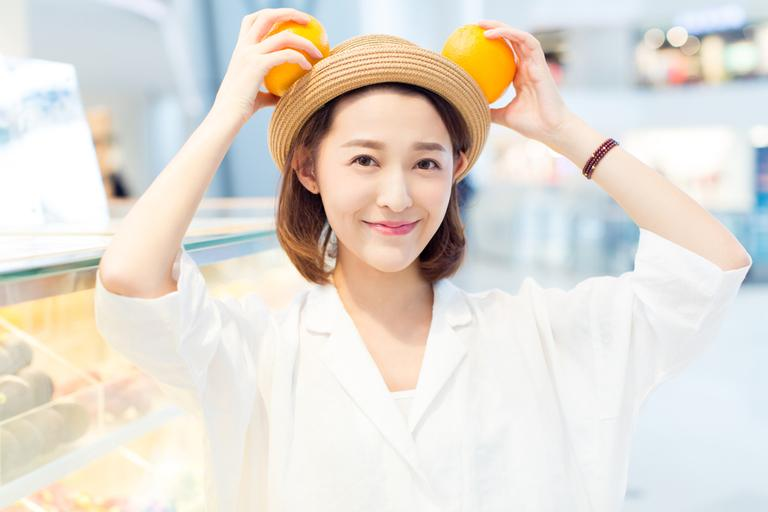

In [4]:
import random
from PIL import Image
import glob

BASE_DIR = "dataset"
image_path = os.path.join(BASE_DIR, "train")
image_path_list = glob.glob(os.path.join(image_path, "*/*.jpg"))

random_image_path = random.choice(image_path_list)
image_class = os.path.basename(os.path.dirname(random_image_path))

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

Let's get started with transforming the data.

In [5]:
from torch import nn
from torchvision import transforms

manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Let's start creating the `dataloader`.

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_data = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "train"),
    transform=manual_transforms,
    target_transform=None
)

Checking the names of the classes that are present in the loaded images.

In [7]:
train_data.classes

['ai', 'real']

In [ ]:
train_data.class_to_idx

{'ai': 0, 'real': 1}

In [9]:
len(train_data)

79950

In [10]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[ 0.4679, -0.3198,  0.1426,  ...,  2.0948,  2.0948,  2.0434],
         [ 0.7419,  0.1768,  0.4337,  ...,  2.1290,  2.1462,  2.1804],
         [-0.1486,  0.2111,  0.3823,  ...,  2.1633,  2.1804,  2.1975],
         ...,
         [-0.7993, -1.1418, -1.0904,  ..., -1.4843, -1.4672, -1.4672],
         [-1.0904, -1.2959, -1.1589,  ..., -1.4158, -1.3987, -1.3987],
         [-1.2103, -1.3987, -1.2445,  ..., -1.3815, -1.3644, -1.3644]],

        [[-0.2325, -1.0378, -0.4776,  ...,  2.2710,  2.2710,  2.2185],
         [ 0.1352, -0.4601, -0.1450,  ...,  2.3060,  2.3235,  2.3585],
         [-0.6176, -0.3200, -0.1275,  ...,  2.3410,  2.3585,  2.3761],
         ...,
         [-1.5105, -1.7031, -1.7031,  ..., -0.7927, -0.7752, -0.7577],
         [-1.6331, -1.7206, -1.6681,  ..., -0.7577, -0.7402, -0.7227],
         [-1.6506, -1.7206, -1.7031,  ..., -0.7227, -0.7052, -0.6877]],

        [[-0.9330, -1.5779, -1.0550,  ...,  2.4831,  2.4831,  2.4308],
         [-0.5321, -0.9678, -0.

Let's start creating the `dataloader`.

In [11]:
from torch.utils.data import dataloader

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

train_dataloader

In [12]:
img, label = next(iter(train_dataloader))
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


In [13]:
import torchvision

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [14]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

Let's get the pre-trained model.

In [15]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

Let's freeze all the `feature extraction` layers in the model.

In [16]:
for param in model.features.parameters():
    param.requires_grad = False

Let's define the `classifier` for the model.

In [17]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(train_data.classes)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(
        in_features=1280,
        out_features=output_shape,
        bias=True
    )
).to(device)

Define the `Loss function` and the `Optimizer` for the model training.

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training loop for the model.

In [19]:
from tqdm import tqdm

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    loop = tqdm(train_dataloader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=True)

    for batch_idx, (inputs, targets) in enumerate(train_dataloader):
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5]:   0%|          | 0/2499 [00:00<?, ?it/s]

Epoch [1/5], Loss: 0.6984


Epoch [1/5]:   0%|          | 0/2499 [06:56<?, ?it/s]


Epoch [2/5], Loss: 0.6982


Epoch [2/5]:   0%|          | 0/2499 [06:59<?, ?it/s]


Epoch [3/5], Loss: 0.6982


Epoch [3/5]:   0%|          | 0/2499 [06:53<?, ?it/s]


Epoch [4/5], Loss: 0.6984


Epoch [4/5]:   0%|          | 0/2499 [07:03<?, ?it/s]


Epoch [5/5], Loss: 0.6993


Saving the model.

In [20]:
torch.save(model.state_dict(), "veriface_v1.pth")